In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/abzohiani/Documents/Energy Data Analytics Career Plan/df_fuel_ckan.csv")


In [3]:
df.head()

,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
0,2009-01-01T00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246.0,2518.0,0.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
1,2009-01-01T00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245.0,2495.0,0.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2,2009-01-01T01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246.0,2465.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
3,2009-01-01T01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246.0,2439.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
4,2009-01-01T02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246.0,2363.0,0.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [4]:
df.shape

(309931, 34)

The number of rows represent 17 years of historic generation mix and carbon intensity data. We want to focus on 2025 data for easy Exploratory Data Analysis for one calendar year. I will later filter the DataFrame to account for only 2025 data.

In [5]:
df.columns

Index(['DATETIME', 'GAS', 'COAL', 'NUCLEAR', 'WIND', 'WIND_EMB', 'HYDRO',
       'IMPORTS', 'BIOMASS', 'OTHER', 'SOLAR', 'STORAGE', 'GENERATION',
       'CARBON_INTENSITY', 'LOW_CARBON', 'ZERO_CARBON', 'RENEWABLE', 'FOSSIL',
       'GAS_perc', 'COAL_perc', 'NUCLEAR_perc', 'WIND_perc', 'WIND_EMB_perc',
       'HYDRO_perc', 'IMPORTS_perc', 'BIOMASS_perc', 'OTHER_perc',
       'SOLAR_perc', 'STORAGE_perc', 'GENERATION_perc', 'LOW_CARBON_perc',
       'ZERO_CARBON_perc', 'RENEWABLE_perc', 'FOSSIL_perc'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309931 entries, 0 to 309930
Data columns (total 34 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATETIME          309931 non-null  str    
 1   GAS               309931 non-null  float64
 2   COAL              309931 non-null  float64
 3   NUCLEAR           309931 non-null  float64
 4   WIND              309931 non-null  float64
 5   WIND_EMB          309931 non-null  float64
 6   HYDRO             309931 non-null  float64
 7   IMPORTS           309931 non-null  float64
 8   BIOMASS           309931 non-null  float64
 9   OTHER             309931 non-null  float64
 10  SOLAR             309931 non-null  float64
 11  STORAGE           309931 non-null  float64
 12  GENERATION        309931 non-null  float64
 13  CARBON_INTENSITY  309931 non-null  float64
 14  LOW_CARBON        309931 non-null  float64
 15  ZERO_CARBON       309931 non-null  float64
 16  RENEWABLE         309931 non-nu

The 'DATETIME' column currently has a 'str' data type. This is OK for now for DataFrame filtering purposes but will need to be later changed to a 'datetime' data type for time series analysis.

In [7]:
df_2025 = df[df["DATETIME"].str.contains("2025")] 
# Filter for 2025 data only. We should only have 17520 rows in the new DataFrame

In [8]:
df_2025.shape

(17520, 34)

In [9]:
df_2025["DATETIME"] = pd.to_datetime(df_2025["DATETIME"])

In [10]:
df_2025["DATETIME"].dtype

dtype('<M8[us]')

This is internal NumPy representation for a 64-bit datetime column with microsecond precision. NESO specifies the timestamps in this dataset as UTC.

In [11]:
# Breaking down the DATETIME column to create time variables
df_2025["HOUR"] = df_2025["DATETIME"].dt.hour
df_2025["DAY_OF_WEEK"] = df_2025["DATETIME"].dt.day_name()
df_2025["DATE"] = df_2025["DATETIME"].dt.date

In [12]:
df_2025[["DATETIME", "HOUR", "DAY_OF_WEEK", "DATE"]].head()

,DATETIME,HOUR,DAY_OF_WEEK,DATE
280512,2025-01-01 00:00:00,0,Wednesday,2025-01-01
280513,2025-01-01 00:30:00,0,Wednesday,2025-01-01
280514,2025-01-01 01:00:00,1,Wednesday,2025-01-01
280515,2025-01-01 01:30:00,1,Wednesday,2025-01-01
280516,2025-01-01 02:00:00,2,Wednesday,2025-01-01


In [13]:
# Check missing values of carbon intensity. 
# Not expecting any as calling df.info earlier gave us all rows in every column as non-null
df_2025["CARBON_INTENSITY"].isna().sum()

np.int64(0)

In [14]:
# Check duplicates. Not expecting any.
df_2025.duplicated().sum()

np.int64(0)

In [15]:
# Check the carbon intensity distribution
df_2025["CARBON_INTENSITY"].describe()

count    17520.000000
mean       126.854167
std         58.453387
min         22.000000
25%         76.000000
50%        120.000000
75%        171.000000
max        295.000000
Name: CARBON_INTENSITY, dtype: float64

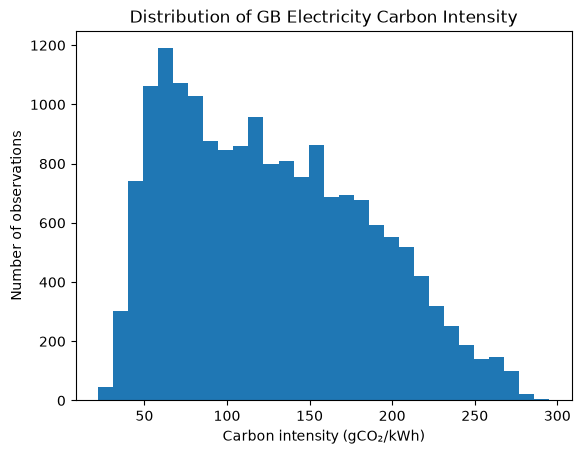

In [16]:
# What does carbon intensity look like overall? Plot a histogram
plt.hist(df_2025["CARBON_INTENSITY"], bins=30)

plt.xlabel("Carbon intensity (gCO₂/kWh)")
plt.ylabel("Number of observations")
plt.title("Distribution of GB Electricity Carbon Intensity")

plt.show()




The distribution is not symmetrical and is right skewed. The peak with the highest number of observations is around 60 gCO2/kWh. This is below the mean of 127 and median of 120 gCO2/kWh. There are three major peaks, around 60, 120, and 150 gCO2/kWh. The highest carbon intensity value is 295 gCO2/kWh which will correspond to a period of fossil fuel dominated generation. The lowest is 22 gCO2/kWh, corresponding to a high share of low-carbon/renewable generation.


In [17]:
# Carbon intensity throughout the day

hourly_ci = (
    df_2025.groupby("HOUR")["CARBON_INTENSITY"]
      .mean()
)

hourly_ci



HOUR
0     114.752055
1     114.030137
2     112.595890
3     112.787671
4     116.100000
5     123.223288
6     130.505479
7     131.643836
8     126.327397
9     118.824658
10    112.379452
11    108.939726
12    107.964384
13    109.061644
14    114.398630
15    126.230137
16    142.745205
17    155.494521
18    160.947945
19    160.298630
20    155.334247
21    144.410959
22    128.082192
23    117.421918
Name: CARBON_INTENSITY, dtype: float64

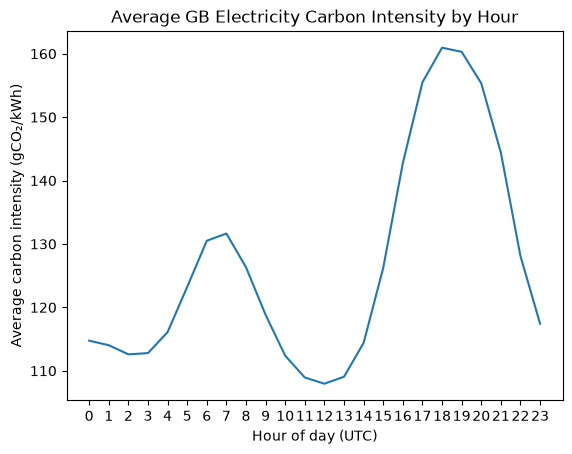

In [18]:
# Plot carbon intensity vs hour of day

plt.plot(hourly_ci.index, hourly_ci.values)

plt.xlabel("Hour of day (UTC)")
plt.ylabel("Average carbon intensity (gCO₂/kWh)")
plt.title("Average GB Electricity Carbon Intensity by Hour")

plt.xticks(range(0, 24))

plt.show()


Average carbon intensity appears to vary considerably over the 24-hour period, with identifiable periods of higher and lower intensity. Notably there are two peaks at around 07:00 and 18:00, and two troughs at 02:00 and 12:00.

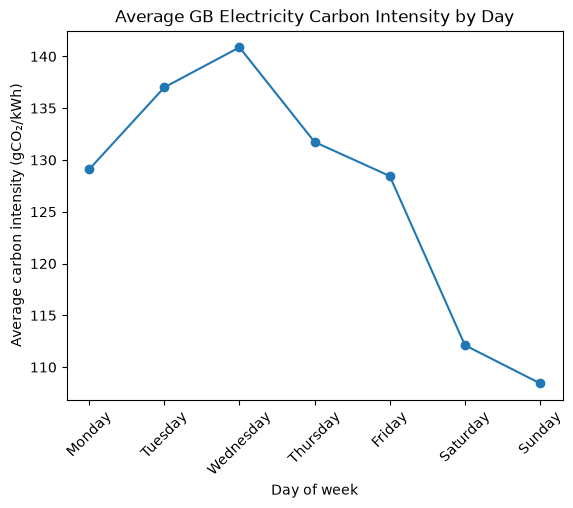

In [19]:
# Carbon intensity by day of week

# Aggregation
daily_ci = (
    df_2025.groupby("DAY_OF_WEEK")["CARBON_INTENSITY"]
      .mean()
)

# Defining weekday order for Python to not sort weekdays alphabetically!
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_ci = daily_ci.reindex(day_order)

# Plotting

plt.plot(daily_ci.index, daily_ci.values, marker="o")

plt.xlabel("Day of week")
plt.ylabel("Average carbon intensity (gCO₂/kWh)")
plt.title("Average GB Electricity Carbon Intensity by Day")

plt.xticks(rotation=45)

plt.show()


Carbon intensity differs systematically between weekdays and weekends. It is higher on weekdays than weekends as expected, with a weekday peak on Wednesday. Notably Monday has a similar carbon intensity to Friday but they are both lower than other weekdays. This may be due to more people working from home on those days.

In [20]:
# Combine hour + day of week for a carbon intensity matrix


# Create pivot table
hour_day_ci = df_2025.pivot_table(
    values="CARBON_INTENSITY",
    index="HOUR",
    columns="DAY_OF_WEEK",
    aggfunc="mean"
)

hour_day_ci = hour_day_ci.reindex(columns=day_order)

hour_day_ci

DAY_OF_WEEK,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
HOUR,,,,,,,
0,105.903846,117.125000,125.084906,122.134615,117.663462,113.394231,101.759615
1,106.076923,116.625000,124.867925,121.057692,116.836538,111.153846,101.384615
2,105.384615,115.711538,123.698113,118.663462,115.278846,108.605769,100.615385
3,106.855769,116.653846,124.028302,118.346154,115.682692,107.894231,99.836538
4,112.442308,120.990385,129.037736,123.673077,120.326923,107.701923,98.278846
5,122.961538,130.509615,139.518868,132.365385,130.230769,108.653846,98.009615
6,132.951923,142.048077,149.820755,141.807692,138.528846,109.663462,98.346154
7,136.278846,144.682692,151.103774,142.288462,137.923077,111.432692,97.423077
8,130.201923,139.230769,145.443396,134.586538,130.403846,108.336538,95.721154


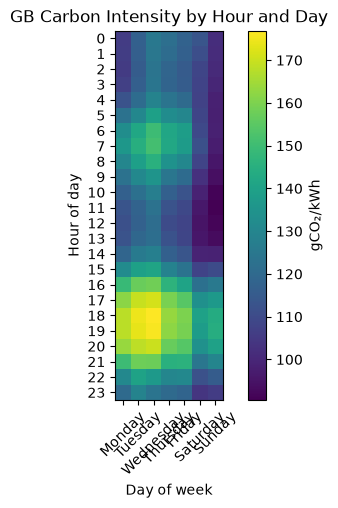

In [21]:
# Plotting 

plt.imshow(hour_day_ci)

plt.xlabel("Day of week")
plt.ylabel("Hour of day")
plt.title("GB Carbon Intensity by Hour and Day")

plt.xticks(
    range(len(hour_day_ci.columns)),
    hour_day_ci.columns,
    rotation=45
)

plt.yticks(range(24), range(24))

plt.colorbar(label="gCO₂/kWh")

plt.show()


From this heatmap, average weekly carbon intensity is highest on Tuesday and Wednesday between 17:00 and 20:00. It is lowest in the first 13 hours of Sunday.

In [27]:
# Analysing carbon intensity and generation mix on hourly basis on Wednesdays and Sundays

daily_comparison = (
    df_2025[df_2025["DAY_OF_WEEK"].isin(["Wednesday", "Sunday"])]
    .groupby(["DAY_OF_WEEK", "HOUR"])[
        ["CARBON_INTENSITY", "GAS", "WIND", "SOLAR", "NUCLEAR"]
    ]
    .mean()
)

weds_gen = daily_comparison.loc["Wednesday"]
print(weds_gen)

sunday_gen = daily_comparison.loc["Sunday"]
print(sunday_gen)

      CARBON_INTENSITY           GAS         WIND        SOLAR      NUCLEAR
HOUR                                                                       
0           125.084906   7216.858491  7555.830189     0.000000  3944.688679
1           124.867925   7172.528302  7432.264151     0.000000  3946.367925
2           123.698113   7017.556604  7316.858491     0.000000  3946.443396
3           124.028302   7059.896226  7229.443396     0.009434  3945.858491
4           129.037736   7583.396226  7197.094340    31.679245  3948.358491
5           139.518868   8876.990566  7187.849057   285.254717  3950.547170
6           149.820755  10541.028302  7155.235849   892.726415  3947.650943
7           151.103774  11446.198113  7090.367925  1943.188679  3944.801887
8           145.443396  11372.235849  7091.311321  3286.867925  3941.113208
9           135.320755  10816.047170  7162.764151  4809.292453  3937.537736
10          127.301887  10284.915094  7159.688679  6032.594340  3932.443396
11          

Text(0.5, 1.0, 'Average Gas Generation by Hour on Wednesdays')

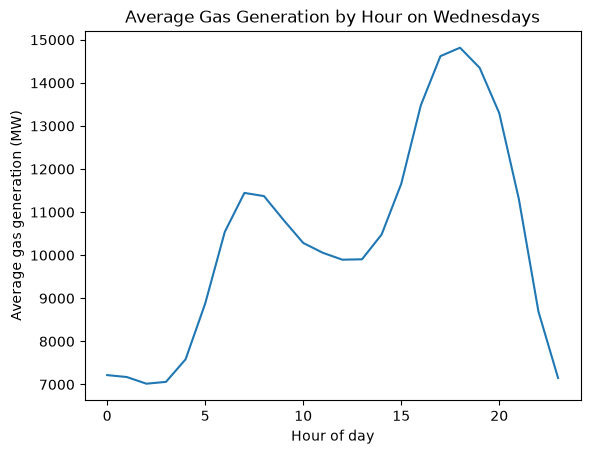

In [23]:
# Plot average gas generation by hour on Wednesdays

plt.plot(
    weds_gen.index,
    weds_gen["GAS"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average gas generation (MW)")
plt.title("Average Gas Generation by Hour on Wednesdays")


Text(0.5, 1.0, 'Average Gas Generation by Hour on Sundays')

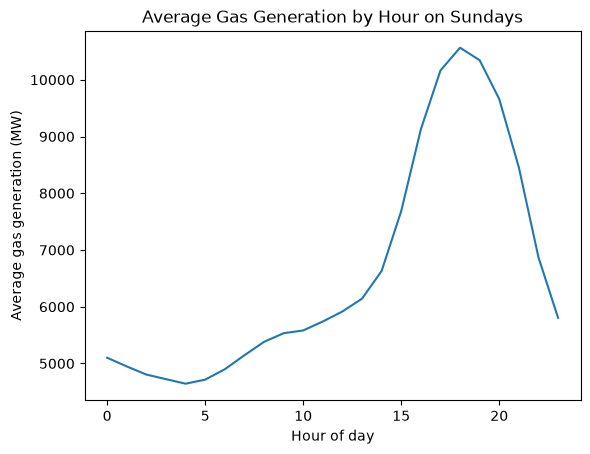

In [24]:
# Plot average gas generation by hour on Sundays

plt.plot(
    sunday_gen.index,
    sunday_gen["GAS"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average gas generation (MW)")
plt.title("Average Gas Generation by Hour on Sundays")

Comparing average gas generation on Wednesdays and Sundays from the two charts above, we can see that overall gas generation is smaller on Sundays, with a peak of 10,565 MW at 18:00 compared with a Wednesday peak of 14,817 at 18:00. Also notably there is only one peak on Sunday whereas there is a smaller Wednesday peak at 07:00 in addition to the larger Wednesday evening peak.

Text(0.5, 1.0, 'Average Wind Generation by Hour on Wednesdays')

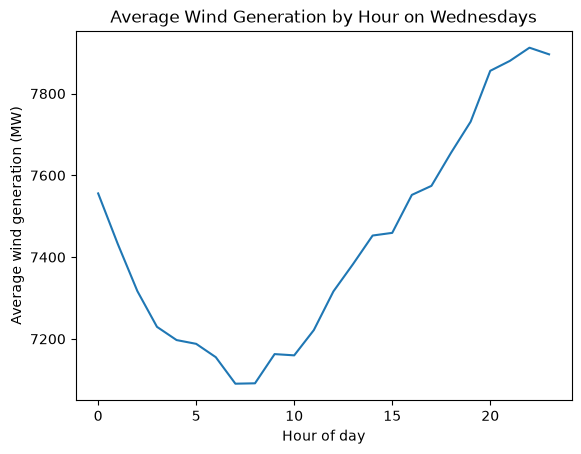

In [28]:
# Plot average wind generation by hour on Wednesdays

plt.plot(
    weds_gen.index,
    weds_gen["WIND"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average wind generation (MW)")
plt.title("Average Wind Generation by Hour on Wednesdays")


Text(0.5, 1.0, 'Average Wind Generation by Hour on Sundays')

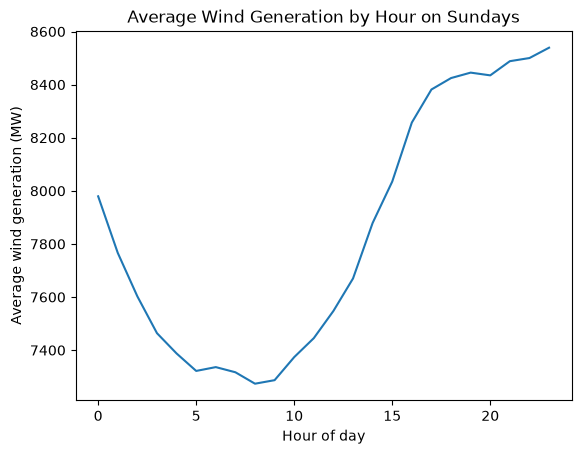

In [29]:
# Plot average wind generation by hour on Sundays

plt.plot(
    sunday_gen.index,
    sunday_gen["WIND"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average wind generation (MW)")
plt.title("Average Wind Generation by Hour on Sundays")

Comparing average wind generation on Wednesdays and Sundays from the two charts above, there is more commonality between them than for gas generation. The trend is for more wind generation during night hours than daytime hours. There is more wind generated on Sunday with a peak of 8539 MW at 23:00, compared with a peak of 7912 MW at 22:00 on Wednesday.

Text(0.5, 1.0, 'Average Solar Generation by Hour on Wednesdays')

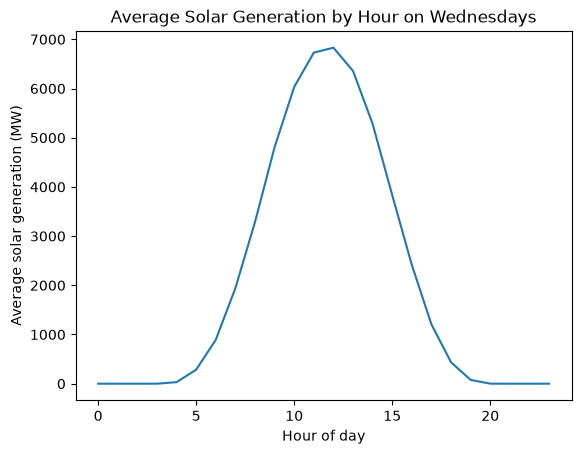

In [30]:
# Plot average solar generation by hour on Wednesdays

plt.plot(
    weds_gen.index,
    weds_gen["SOLAR"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average solar generation (MW)")
plt.title("Average Solar Generation by Hour on Wednesdays")

Text(0.5, 1.0, 'Average Solar Generation by Hour on Sundays')

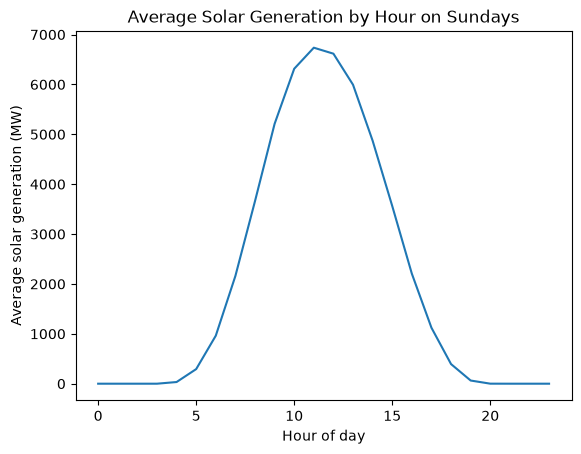

In [31]:
# Plot average solar generation by hour on Sundays

plt.plot(
    sunday_gen.index,
    sunday_gen["SOLAR"]
)

plt.xlabel("Hour of day")
plt.ylabel("Average solar generation (MW)")
plt.title("Average Solar Generation by Hour on Sundays")

Solar generation is more consistent across the two days, with peak generation occurring at 11am for both days at just under 7000 MW.

In [34]:
# Find the relationship between carbon intensity and types of generation

df_2025[
    ["CARBON_INTENSITY", "GAS", "WIND", "SOLAR", "NUCLEAR"]
].corr()


,CARBON_INTENSITY,GAS,WIND,SOLAR,NUCLEAR
CARBON_INTENSITY,1.000000,0.926243,-0.590453,-0.306333,-0.096082
GAS,0.926243,1.000000,-0.378719,-0.230562,-0.031874
WIND,-0.590453,-0.378719,1.000000,-0.179594,-0.006568
SOLAR,-0.306333,-0.230562,-0.179594,1.000000,0.036259
NUCLEAR,-0.096082,-0.031874,-0.006568,0.036259,1.000000


Carbon intensity and gas generation show a strong positive association in this dataset as expected. There is a negative correlation between carbon intensity and renewable generation (wind and solar), with wind generation being less carbon intensive. There is a very weak negative association between carbon intensity and nuclear power generation.

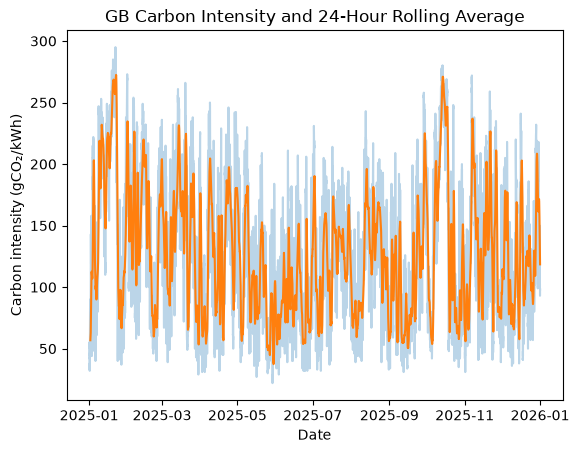

In [54]:
# Rolling average carbon intensity across the whole of 2025

df_2025 = df_2025.sort_values("DATETIME")

df_2025["ci_24h_avg"] = (
    df_2025["CARBON_INTENSITY"]
    .rolling(48)
    .mean()
)

plt.plot(
    df_2025["DATETIME"],
    df_2025["CARBON_INTENSITY"],
    alpha=0.3
)

plt.plot(
    df_2025["DATETIME"],
    df_2025["ci_24h_avg"]
)

plt.xlabel("Date")
plt.ylabel("Carbon intensity (gCO₂/kWh)")
plt.title("GB Carbon Intensity and 24-Hour Rolling Average")

plt.show()








This yearly overview of carbon-intensity shows that it is highest during winter periods and lowest during summer as expected.